This is an example notebook for putting together a couple of key functions for a differentiable SAS model.

In [1]:
from functools import partial

import pandas as pd
import jax
import jax.numpy as jnp


# Parameter and coefficients

In [2]:
# Number of time step
nt = 5

# Time duration
t_length = 2.

# Time step
dt = t_length / nt

# The maximum age step
τ_max = 3

# The old-water concentration
C_old = 0.0 # [mg/l]

# The first-order reaction rate constant
k1 = 0.0 

# The equilibrium concentration
C_eq = 0.0 # [mg/o]

# Outflow names
keys = 'Q'

# Fractionation
α = 1.


# Flow and solutes in/out

In [3]:
pulse_start1 = 0.05
pulse_end1 = 0.45

pulse_start2 = 1.25
pulse_end2 = 1.45

C_tracer_input1 = 0.5
C_tracer_input2 = 1.5
Q_steady = 1.
Storage_vol = 0.1

# data_df = pd.DataFrame(index=jnp.arange(nt) * dt)
# data_df['Q'] = q_steady
# data_df['J'] = q_steady
# data_df['C_J'] = c_tracer_input
# data_df.loc[pulse_start:pulse_end, 'C_J'] = 0.5
data_df = pd.DataFrame(index=jnp.arange(nt) * dt)
data_df['Q'] = Q_steady
data_df['J'] = Q_steady
data_df['C_J'] = 0
data_df.loc[pulse_start1:pulse_end1, 'C_J'] = C_tracer_input1
data_df.loc[pulse_start1:pulse_end1, 'J'] = Q_steady * 2
data_df.loc[pulse_start1:pulse_end1, 'Q'] = Q_steady / 20.


2025-01-06 09:42:17.164761: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version (12.6.20). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
/tmp/ipykernel_364055/3582232366.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_df.loc[pulse_start1:pulse_end1, 'C_J'] = C_tracer_input1


In [4]:
data_df['C_J']

0.0    0.0
0.4    0.5
0.8    0.0
1.2    0.0
1.6    0.0
Name: C_J, dtype: float64

<Axes: >

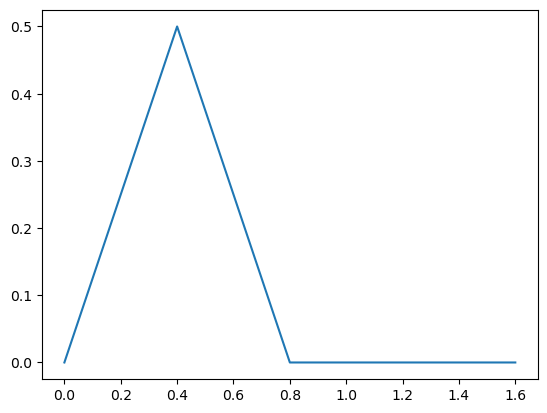

In [5]:
data_df['C_J'].plot()


# Change of flow and solute rates

In [141]:
# # Change of flow rate
# # TODO: assume only streamflow for now; add ET in the future
# def fs(sT, pQ, J_τ_t, Q_t, dt):
#     in_flow = J_τ_t
#     out_flow = Q_t * pQ
#     return (in_flow - out_flow) / dt

# # Change of solute rate
# # TODO: assume only streamflow for now; add ET in the future
# def fm(sT, mT, sas, ST, J_τ_t, C_J_τ_t, Q_t, α, k1, C_eq, dt):
#     in_sol = J_τ_t * C_J_τ_t
#     return (in_sol - mQ + mR) / dt

# Combined forward function
def f(states, ST, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt):
    sT, mT = states
    # Calculate the pQ, mQ, and mR
    PQ1, PQ2 = sas(ST+sT*dt), sas(ST)
    pQ = (PQ1 - PQ2) / dt
    mQ = compute_mQ(sT, mT, α, Q_t, pQ)
    mR = compute_mR(sT, mT, k1, C_eq)
    
    # Update the change of sT and mT
    δs = (J_τ_t - Q_t * pQ * dt) / dt

    # Update the change of sT and mT
    δm = (J_τ_t * C_J_τ_t - mQ * dt + mR * dt) / dt
    # jax.debug.print('δs: {s}; δm: {m}', s=δs, m=δm)
    # jax.debug.print('sT: {x}; mT: {x2}; Q_t: {x3}; pQ: {x4} mQ: {s}; mR: {m}', x=sT, x2=mT, x3=Q_t, x4=pQ, s=mQ, m=mR)
    # jax.debug.print('J_τ_t, Q_t, sT, δs, pQ, ST, ST+sT*dt: {x1}, {q}, {x2}, {x3}, {a}, {b}, {c}', x1=J_τ_t, q=Q_t, x2=sT, x3=δs, a=pQ, b=ST, c=ST+sT*dt)
    # jax.debug.print('J_τ_t, Q_t, sT, δs, pQ: {x1}, {q}, {x2}, {x3}, {a}', x1=J_τ_t, q=Q_t, x2=sT, x3=δs, a=pQ)
    jax.debug.print('J_τ_t, Q_t, sT, sT+δs*dt, ST, ST+sT*dt, pQ: {x1}, {q}, {x2}, {x3}, {x4}, {x5}, {a}', x1=J_τ_t, q=Q_t, x2=sT, x3=sT+δs*dt, x4=ST, x5=ST+sT*dt, a=pQ)
    return jnp.array([δs, δm]), pQ, mQ, mR
    

In [7]:
# Compute mQ -- mass loss with flow
def compute_mQ(sT, mT, α, Q_t, pQ):
    # return mT / sT * (α * Q_t * pQ)
    # return jnp.where(sT == 0.0, 0.0, mT / sT * (α * Q_t * pQ))
    part_a = mT * (α * Q_t * pQ)
    y = jnp.where(sT == 0.0, 1.0, sT)
    part_b = jnp.where(sT == 0.0, 0.0, 1./ y)
    return part_a * part_b

# Compute mR -- Reaction rate
def compute_mR(sT, mT, k1, C_eq):
    return k1 * (C_eq*sT - mT)
    

# (TODO) Data-driven SAS function

In [8]:
# Neural likelihood?
def sas(Si, loc=0., scale=1., t=None):
    pass


In [32]:
def sas_gamma(Si, a, loc=0., scale=1.):
    return jax.scipy.stats.gamma.cdf(Si, a, loc, scale)
    

In [46]:
def sas_beta(Si, a, b, loc=0., scale=1.):
    return jax.scipy.stats.beta.cdf(Si, a, b, loc, scale)
    # x = (Si - loc) / scale
    # return jax.scipy.special.betainc(a, b, x)
    

In [66]:
def sas_kumaraswamy(Si, a, b, loc=0., scale=1.):
    x = (Si - loc) / scale
    x = jax.lax.min(jax.lax.max(0., x), 1.)
    return 1. - (1. - x**a) ** b
    # return jax.scipy.special.betainc(a, b, x)
    

In [48]:
# sas2 = partial(sas_gamma, a=0.02)
# sas1 = partial(sas_beta, a=2.31, b=0.627)
# sas1(2.)

# Function for calculating the actual flow concentration

In [11]:
# def calculate_cq(mQ, Q, st, c_old):
#     # mq: (τ_max, nt)
#     # q: (nt,)
#     # st: (τ_max, nt)
#     c1 = mq.sum(axis=0) / q  # (nt,)
#     c2 = c_old * (1 - sas(st[:,-1]))  # (nt,)
#     return c1 - c2
    

# Explicit Euler solver

In [12]:
# def odeint_rk4(f, y0, t, *args):
#     def step(state, t):
#         y_prev, t_prev = state
#         h = t - t_prev
#         k1 = h * f(y_prev, t_prev, *args)
#         k2 = h * f(y_prev + k1/2., t_prev + h/2., *args)
#         k3 = h * f(y_prev + k2/2., t_prev + h/2., *args)
#         k4 = h * f(y_prev + k3, t + h, *args)
#         y = y_prev + 1./6 * (k1 + 2 * k2 + 2 * k3 + k4)
#         return (y, t), y
#     _, ys = jax.lax.scan(step, (y0, t[0]), t[1:])
#     return ys

In [13]:
# odeint_rk4 = jax.custom_jvp(odeint_rk4, nondiff_argnums=(0,))

# @odeint_rk4.defjvp
# def odeint_rk4_jax_jvp(f, primals, tangents):
#     y0, t, *args = primals
#     delta_y0, _, *delta_args = tangents
#     nargs = len(args)
    
#     def f_aug(aug_state, t, *args_and_delta_args):
#         primal_state, tangent_state = aug_state
#         args, delta_args = args_and_delta_args[:nargs], args_and_delta_args[nargs:]
#         primal_dot, tangent_dot = jax.jvp(f, (primal_state, t, *args), (tangent_state, 0., *delta_args))
#         return jnp.stack([primal_dot, tangent_dot])

#     aug_init_state = jnp.stack([y0, delta_y0])
#     aug_states = odeint_rk4(f_aug, aug_init_state, t, *args, *delta_args)
#     ys, ys_dot = aug_states[:, 0, :], aug_states[:, 1, :]
#     return ys, ys_dot


In [14]:
def solve_step_rk4(states, ST_top, ST_bot, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt):
    # sT, mT, ST_top, ST_bot: (1,)
    # J_τ, C_J, Q: (nt,)
    ST_mid = (ST_top + ST_bot) / 2

    # Note: we use relu to make sure the updated states are non-zero
    r1, pQ1, mQ1, mR1 = f(states, ST_top, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt)
    states1 = jax.nn.relu(states+0.5*r1*dt)
    r2, pQ2, mQ2, mR2 = f(states1, ST_mid, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt)
    states2 = jax.nn.relu(states+0.5*r2*dt)
    r3, pQ3, mQ3, mR3 = f(states2, ST_mid, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt)
    states3 = jax.nn.relu(states+r3*dt)
    r4, pQ4, mQ4, mR4 = f(states3, ST_bot, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt)
    # jax.debug.print('\n')

    states_new = jax.nn.relu(states + 1./6 * (r1 + 2 * r2 + 2 * r3 + r4) * dt)
    pQ = 1./6 * (pQ1 + 2 * pQ2 + 2 * pQ3 + pQ4)
    mQ = 1./6 * (mQ1 + 2 * mQ2 + 2 * mQ3 + mQ4)
    mR = 1./6 * (mR1 + 2 * mR2 + 2 * mR3 + mR4)
    # jax.debug.print('states: {x}', x=states)
    # jax.debug.print('states_new: {x}', x=states_new)

    return states_new, pQ, mQ, mR


In [143]:
def solve_step_rk2(states, ST_top, ST_bot, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt):
    # sT, mT, ST_top, ST_bot: (1,)
    # J_τ, C_J, Q: (nt,)
    ST_mid = (ST_top + ST_bot) / 2

    # Note: we use relu to make sure the updated states are non-zero
    r1, pQ1, mQ1, mR1 = f(states, ST_top, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt)
    states1 = jax.nn.relu(states+1.*r1*dt)
    r2, pQ2, mQ2, mR2 = f(states1, ST_bot, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt)

    states_new = jax.nn.relu(states + (r1 + r2)/2. * dt)
    pQ = 1./2 * (pQ1 + pQ2)
    mQ = 1./2 * (mQ1 + mQ2)
    mR = 1./2 * (mR1 + mR2)
    # states_new = jax.nn.relu(states + r2 * dt)
    # pQ = pQ2
    # mQ = mQ2
    # mR = mR2
    jax.debug.print('states: {x1}; r1: {x2}; states1: {x3}; r2: {x4}; states_new: {x5}; ST_top: {x6}; ST_bot: {x7}; pQ1: {x8}; pQ2: {x9}.', 
                    x1=states, x2=r1, x3=states1, x4=r2, x5=states_new, x6=ST_top, x7=ST_bot, x8=pQ1, x9=pQ2)

    return states_new, pQ, mQ, mR


In [97]:
def solve_step_euler(states, ST_top, ST_bot, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt):
    # sT, mT, ST_top, ST_bot: (1,)
    # J_τ, C_J, Q: (nt,)

    r, pQ, mQ, mR = f(states, ST_top, J_τ_t, C_J_τ_t, Q_t, sas, α, k1, C_eq, dt)

    states_new = jax.nn.relu(states + r * dt)

    return states_new, pQ, mQ, mR


# Solve the ODE system

In [125]:
def solve_sas(
    J_full, C_J, Q, J, dt,
    sT_init, mT_init,
    sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old,
    sas_func,
    α, k1, C_eq
):
    # Arguments
    args = [α, k1, C_eq, dt]

    # Initials at age 
    initials = [sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old]
    
    def step_age(state, x):
        # sT_init_τ : (1,,)
        # J_τ : (nt,)
        sT_init_τ, mT_init_τ, J_τ = x
    
        # sT, mT, ST, C_Q : (nt,)
        sT, mT, ST_top, ST_bot, C_Q, P_Q_old  = state
    
        # Solve the ODE system
        sT_mT = jnp.concat([sT[:,None], mT[:,None]], axis=1)
        states_updated, pQ_new, mQ_new, mR_new = jax.vmap(
            solve_step_rk2, in_axes=(0,0,0,0,0,0,None,None,None,None,None))(
            sT_mT, ST_top[:-1], ST_bot[:-1], J_τ, C_J, Q, sas_func, *args
        )
        sT_new, mT_new = states_updated[:,0], states_updated[:,1]
        jax.debug.print('sT, mT: {x1}, {x2}', x1=sT, x2=mT)
        jax.debug.print('sT_new, mT_new: {x1}, {x2}', x1=sT_new, x2=mT_new)
        jax.debug.print('\n')

        # Check zeros

        # Update ST
        ST_top_new = ST_bot
        ST_bot_new = jnp.concat([sT_init_τ[None] * dt, ST_bot[1:] + sT_new * dt])
        # ST_bot_new = jnp.concat([ST_bot[:-1] + sT_new * dt, (ST_bot[-1]+sT[-1]*dt)[None]])
        # ST_bot_new = jnp.concat([sT_init_τ[None], (ST_bot[-1]+sT_new[-1]*dt)[None], ST_bot[:-2] + sT_new[:-1] * dt])
        # ST_bot_new = jnp.concat([jnp.array([0]), (ST_bot[-1]+sT_new[-1]*dt)[None], ST_bot[:-2] + sT_new[:-1] * dt])
        # ST_bot_new = jnp.concat([ST_bot[:-1] + sT_new * dt, (ST_bot[-1]+sT_new[-1]*dt)[None]])
    
        # Update P_Q
        P_Q_old_new = P_Q_old - pQ_new * dt
        
        # Update C_Q
        C_Q_new = C_Q + mQ_new * dt / Q
        
        # Variables to save
        state_to_save = [sT_new, mT_new, mQ_new, pQ_new, C_Q_new, P_Q_old_new]
    
        # Variables as the initial condition to the next step
        sT_new_rotate = jnp.concat([sT_init_τ[None],sT_new[:-1]])
        mT_new_rotate = jnp.concat([mT_init_τ[None],mT_new[:-1]])
    
        state_to_rotate = [sT_new_rotate, mT_new_rotate, ST_top_new, ST_bot_new, C_Q_new, P_Q_old_new]
        
        return state_to_rotate, state_to_save
    
    _, states = jax.lax.scan(step_age, initials, [sT_init, mT_init, J_full])
    
    sT, mT, mQ, pQ, C_Q, P_Q_old = states

    sT = jnp.concat([sT_init[:,None], sT], axis=1)
    mT = jnp.concat([mT_init[:,None], mT], axis=1)
    
    
    # Add old age concentration to C_Q
    C_Q = C_Q[-1] + C_old * P_Q_old[-1]

    # # Get the exact flux extracted at each age step
    # pQ_flux = pQ * dt * Q

    return sT, mT, mQ, C_Q, pQ


# Run SAS

In [133]:
C_J = jnp.array(data_df['C_J'].values) # (nt)
Q = jnp.array(data_df['Q'].values) # (nt,)
J = jnp.array(data_df['J'].values) # (nt,)
J_full = jnp.concat([J[None,:], jnp.zeros([τ_max-1, nt])])

# Initial sT and mT at time = 0
# sT_init, mT_init = jnp.zeros(τ_max), jnp.zeros(τ_max)
sT_init, mT_init = jnp.array([10., 15., 20.]), jnp.array([10., 10., 10.])

# Initials at age = 0
sT_0, mT_0 = jnp.zeros(nt), jnp.zeros(nt)
ST_top_0, ST_bot_0 = jnp.zeros(nt+1), jnp.zeros(nt+1) 
C_Q_0, P_old = jnp.zeros(nt), jnp.ones(nt) 
# initials = [sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old]

# SAS function
# sas_func = partial(sas_gamma, a=0.02)
# sas_func = partial(sas_beta, a=2.31, b=0.627)
sas_func = partial(sas_kumaraswamy, a=2.31, b=0.627)


In [ ]:
sT_final, mT_final, mQ_final, C_Q_final, pQ_final = solve_sas(
    J_full, C_J, Q, J, dt,
    sT_init, mT_init,
    sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old,
    sas_func,
    α, k1, C_eq
)
sT_final, mT_final, mQ_final, C_Q_final, pQ_final


In [ ]:
# # Compute mQ -- mass loss with flow
# def compute_mQ(sT, mT, α, Q_t, pQ):
#     # return mT / sT * (α * Q_t * pQ)
#     part_a = mT * (α * Q_t * pQ)
#     y = jnp.where(sT == 0.0, 1.0, sT)
#     part_b = jnp.where(sT == 0.0, 0.0, 1./ y)
#     return part_a * part_b
